In [18]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from upsetplot import UpSet

In [19]:
def anno_is6(is6_path, result_df):
    is6 = pd.read_csv(is6_path, sep="\t", index_col=False, header=None)

    # make cols and split accession col
    header = [
        "UniProt ID",
        "md5",
        "Sequence length",
        "DB",
        "Family ID",
        "Desc",
        "Start",
        "End",
        "Evalue",
        "2",
        "3",
        "InterPro ID",
        "IP name",
        "4",
        "5",
    ]
    # add header
    is6.columns = header

    is6 = is6[["UniProt ID", "DB", "Family ID", "Desc", "Start", "End"]]
    # Check if any values contain "sp|"
    if is6["UniProt ID"].str.contains("sp|", regex=False).any():
        print("fixing fasta header id...")
        is6["UniProt ID"] = is6["UniProt ID"].str.split("|").str[1]
    # print(is6)
    ids = result_df[["uniprot_id"]].drop_duplicates()

    # count pfam/antifam per id
    counts = (
        is6.groupby(["UniProt ID", "DB"]).size().unstack(fill_value=0).reset_index()
    )

    # merge back to keep all ids, even if counts are missing
    summary = ids.merge(
        counts, right_on="UniProt ID", left_on="uniprot_id", how="left"
    ).fillna(0)

    # make sure both columns exist
    for col in ["Pfam", "AntiFam", "MobiDB-lite"]:
        if col not in summary.columns:
            summary[col] = 0

    # clean column names
    summary = summary.rename(
        columns={
            "Pfam": "Pfam count",
            "AntiFam": "AntiFam count",
            "MobiDB-lite": "MobiDB count",
        }
    )
    summary = summary.drop(columns=["UniProt ID"])

    result_df = result_df.merge(summary, how="left", on="uniprot_id")

    result_df["IS6 result"] = ~(
        (result_df["Pfam count"] == 0)
        & (result_df["AntiFam count"] == 0)
        & (result_df["MobiDB count"] == 0)
    )

    return is6, result_df

In [20]:
def get_reasons(id):
    url = f"https://rest.uniprot.org/uniprotkb/{id}.json"
    response = requests.get(url)
    annotation_score = None
    protein_existence = None
    caution = None
    is_fragment = "No"

    if response.status_code != 200:
        print(f"Error occured retrieving data for {id}: {response.status_code}")
        return annotation_score, protein_existence, caution, is_fragment

    try:
        data = response.json()
        annotation_score = data.get("annotationScore")
        protein_existence = data.get("proteinExistence")

        if "comments" in data:
            comments = data["comments"]
            for comment in comments:
                if "CAUTION" in comment.get("commentType", "").upper():
                    if "sequenceCautionType" in comment:
                        caution = comment["sequenceCautionType"]
                    elif "texts" in comment and len(comment["texts"]) > 0:
                        caution = comment["texts"][0]["value"]

        protein_description = data.get("proteinDescription", {})
        if protein_description.get("flag", "").lower() == "fragment":
            is_fragment = "Yes"

    except Exception as e:
        print(f"Error occured retrieving data for {id}: {e}")
    time.sleep(0.1)
    return annotation_score, protein_existence, caution, is_fragment


def anno_reasons(results_df):
    results_df[
        ["annotation_score", "protein_existence_score", "caution", "is_fragment"]
    ] = results_df["uniprot_id"].apply(lambda acc: pd.Series(get_reasons(acc)))
    return results_df

In [21]:
def anno_shadow(shadow_results_csv, results_df):
    shadow_res = {}
    frames = ["1", "2", "3", "-1", "-2", "-3", "Shadow score", "Frameshift score"]
    with open(shadow_results_csv) as sv:
        for line in sv:
            if line.startswith("output"):
                parts = line.strip().split("\t")
                id = parts[0].split(": ")[1]

                shadow_res[id] = {}

                for i, frame in enumerate(frames):
                    shadow_res[id][frame] = parts[i + 1].strip()

    # write shadow res to dataframe, rename "id" col to be "uniprot_id"
    shadow_df = pd.DataFrame.from_dict(shadow_res, orient="index")
    # update column names to be frame keys
    shadow_df = shadow_df.reset_index().rename(columns={"index": "uniprot_id"})
    shadow_df["Shadow score"] = shadow_df["Shadow score"].apply(lambda x: int(x))
    shadow_df["Frameshift score"] = shadow_df["Frameshift score"].apply(
        lambda x: int(x)
    )

    # then merge shadow_res dataframe["shadow_score", "frameshift_score"] with results_df on "uniprot_id"
    results_df = results_df.merge(
        shadow_df[["uniprot_id", "Shadow score", "Frameshift score"]],
        on="uniprot_id",
        how="left",
    )

    return shadow_df, results_df


def anno_spurio(spurio_resfile, results_df):
    sp_res = pd.read_csv(spurio_resfile, sep="\t")
    sp_res.columns = sp_res.columns.str.strip()
    sp_res = sp_res.rename(columns={"Spuriosity score": "Spurio score"})
    sp_res = sp_res.rename(columns={"UniProt Accession": "uniprot_id"})

    sp_res = sp_res[
        ["uniprot_id", "Spurio score", "STOPS per AA", "Homologous Matches"]
    ]

    sp_res["uniprot_id"] = sp_res["uniprot_id"].astype(str).str.strip()

    results_df = results_df.merge(
        sp_res,
        on="uniprot_id",
        how="left",
    )
    return results_df

In [22]:
def run_everything(pred_csv, anno_csv, paths):
    predictions = pd.read_csv(pred_csv, index_col=False, sep=",")

    # Apply annotations
    predictions = anno_spurio(paths["spurio"], predictions)
    shadow_res, predictions = anno_shadow(paths["shadow"], predictions)
    is6_res, predictions = anno_is6(paths["is6"], predictions)
    if "anno_data" in paths.keys():
        anno_data = pd.read_csv(paths["anno_data"], sep="\t")
        anno_cols = [
            "uniprot_id",
            "annotation_score",
            "protein_existence_score",
            "caution",
            "is_fragment",
        ]
        predictions = predictions.merge(
            anno_data[anno_cols], on="uniprot_id", how="left"
        )
    else:
        predictions = anno_reasons(predictions)
    predictions["protein_existence_score"] = (
        predictions["protein_existence_score"].str.split(": ").str[0]
    )

    # Save annotated results
    predictions.to_csv(anno_csv, index=False, sep=",")

    return predictions, shadow_res, is6_res

In [23]:
def get_spurious(results_df, is6_res):
    results_df = results_df[(results_df["Pfam count"] == 0)]

    condition1 = results_df["Spurio score"] > 0.9
    condition2 = results_df["Frameshift score"] < 0
    condition3 = results_df["Shadow score"] < 0
    condition4 = results_df["AntiFam count"] > 0

    combined_condition = condition1 | condition2 | condition3 | condition4
    filtered_df = results_df[combined_condition]
    filtered_df = filtered_df[
        [
            "uniprot_id",
            "length",
            "pLDDT mean",
            "pae pTM",
            "prediction_score",
            "Shadow score",
            "Frameshift score",
            "Spurio score",
            "AntiFam count",
            "MobiDB count",
            "caution",
            "annotation_score",
            "protein_existence_score",
        ]
    ]

    # sort by spuriosity score (greatest to smallest)
    filtered_df = filtered_df.sort_values(["Spurio score"], ascending=False)
    return filtered_df


def get_pfam(results_df, is6_res):
    results_df = results_df[(results_df["Pfam count"] > 0)]

    results_df = results_df[["uniprot_id", "Pfam count", "length"]]
    # merge is6_res UniProt ID and results_df uniprot_id, keeping the family id and name
    merged_df = results_df.merge(
        is6_res[["UniProt ID", "Family ID", "Desc", "Start", "End"]],
        left_on="uniprot_id",
        right_on="UniProt ID",
        how="left",
    )
    merged_df = merged_df.drop(columns=["UniProt ID"])
    return merged_df

In [24]:
def classify_preds(pred_df):
    # finding real proteins
    pfam_matches = pred_df[pred_df["Pfam count"] > 0]
    evidence_matches = pred_df[pred_df["protein_existence_score"] == "1"]
    genuine = pd.concat([pfam_matches, evidence_matches]).drop_duplicates()
    # filter to remove cautioned sequences
    WGS_MESSAGE = "The sequence shown here is derived from an EMBL/GenBank/DDBJ whole genome shotgun (WGS) entry which is preliminary data"
    genuine = genuine[genuine["caution"].isna() | (genuine["caution"] == WGS_MESSAGE)]

    # finding spurious proteins
    antifam_matches = pred_df[pred_df["AntiFam count"] > 0]
    uncertain = pred_df[pred_df["protein_existence_score"] == "5"]
    shadow_orfs = pred_df[
        (pred_df["Shadow score"] < 0)
        & (pred_df["Shadow score"] < pred_df["Frameshift score"])
    ]
    frameshifts = pred_df[
        (pred_df["Frameshift score"] < 0)
        & (pred_df["Frameshift score"] < pred_df["Shadow score"])
    ]
    spurio_matches = pred_df[pred_df["Spurio score"] > 0.8]

    spurious = pd.concat(
        [antifam_matches, shadow_orfs, frameshifts, spurio_matches, uncertain]
    ).drop_duplicates()

    # finding unknown
    known_ids = set(genuine["uniprot_id"]) | set(spurious["uniprot_id"])
    unknown = pred_df[~pred_df["uniprot_id"].isin(known_ids)]

    # finding singletons in unknown
    singles = unknown[unknown["Shadow score"] == 1]
    # could also include no shadow/spurio matches?

    # checking disordered proteins
    disorder_gen = genuine[genuine["MobiDB count"] > 0]
    disorder_sp = spurious[spurious["MobiDB count"] > 0]
    disorder_remain = unknown[unknown["MobiDB count"] > 0]
    disorder_singles = singles[singles["MobiDB count"] > 0]

    # summarising results
    counts = {
        "Spurious": len(spurious),
        "Genuine": len(genuine),
        "Unknown": len(unknown),
        "Singletons": len(singles),
        "Genuine disordered": len(disorder_gen),
        "Unknown disordered": len(disorder_remain),
        "Spurious disordered": len(disorder_sp),
        "Singletons disordered": len(disorder_singles),
    }
    # collecting categorised dfs
    cat_dfs = {"Spurious": spurious, "Genuine": genuine, "Unknown": unknown}

    return counts, cat_dfs

## Process SPAF Predictions

In [25]:
spaf_paths = {
    "spurio": "../2_gpc_validation/results/spaf/spaf_sequences_summary.txt",
    "is6": "../../data/swiss-prot/2025_03_uniprot_sprot_is6.tsv",
    "shadow": "../2_gpc_validation/results/spaf/shadow_res/results_csv_sp.txt",
    "anno_data": "../../data/swiss-prot/2025_03_uniprot_sprot_anno_afdb.tsv",
}

spaf_predictions, spaf_shadow_res, spaf_is6 = run_everything(
    pred_csv="../1_gpc_run/results/spaf_predictions.csv",
    anno_csv="results/anno_spaf_predictions.csv",
    paths=spaf_paths,
)

fixing fasta header id...


/tmp/ipykernel_3900263/4146687734.py:9: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  anno_data = pd.read_csv(paths["anno_data"], sep="\t")


In [26]:
print(spaf_predictions["caution"].unique())

[nan 'The order of the peptides shown is unknown'
 'Could be the product of a pseudogene' 'Erroneous initiation'
 'Frameshift' 'It is uncertain whether Met-1 or Val-20 is the initiator'
 'Highly divergent compared to other bacterial HisD'
 'This protein may not be real because it is encoded on the opposite frame of insertion element IS406']


In [27]:
# Run classification analysis for spaf
print(len(spaf_predictions))
spaf_sum, spaf_dfs = classify_preds(spaf_predictions)
print(spaf_sum)
# Generate spurious and pfam results for spaf
spurious_spaf_df = get_spurious(spaf_predictions, spaf_is6)

spurious_spaf_df.to_csv(
    "results/spurious_spaf_predictions.tsv",
    index=False,
    sep="\t",
)

pfam_spaf_df = get_pfam(spaf_predictions, spaf_is6)
pfam_spaf_df.to_csv(
    "results/pfam_spaf_predictions.tsv",
    index=False,
    sep="\t",
)

genuine_prots = spaf_dfs["Genuine"]
unknown_prots = spaf_dfs["Unknown"]
genuine_prots.to_csv(
    "results/gen_spaf_predictions.tsv",
    index=False,
    sep="\t",
)
unknown_prots = unknown_prots.sort_values(
    by="Shadow score", ascending=True, na_position="first"
)
unknown_prots.to_csv(
    "results/unknown_spaf_predictions.tsv",
    index=False,
    sep="\t",
)

105
{'Spurious': 37, 'Genuine': 20, 'Unknown': 49, 'Singletons': 1, 'Genuine disordered': 6, 'Unknown disordered': 22, 'Spurious disordered': 17, 'Singletons disordered': 0}


## Process TRAF Predictions

In [28]:
if not os.path.exists("../1_gpc_run/results/traf_predictions_1000.csv"):
    traf_predictions = pd.read_csv(
        "../1_gpc_run/results/spaf_predictions.csv",
        index_col=False,
        sep=",",
    )
    traf_ids = pd.read_csv(
        "../1_gpc_run/results/sequences/traf_1000_ids.txt",
        index_col=False,
        sep="\t",
        header=None,
    )

    traf_predictions_1000 = traf_predictions[
        traf_predictions["uniprot_id"].isin(traf_ids[0])
    ]
    traf_predictions_1000.to_csv(
        "../1_gpc_run/results/traf_predictions_1000.csv",
        index=False,
        sep=",",
    )

else:
    traf_predictions_1000 = pd.read_csv(
        "../1_gpc_run/results/traf_predictions_1000.csv",
        index_col=False,
        sep=",",
    )

In [29]:
# paths for traf annotations
traf_paths = {
    "spurio": "../2_gpc_validation/results/traf_1000/traf_1000_sequences_summary.txt",
    "is6": "../2_gpc_validation/results/traf_1000/traf_1000_is6.tsv",
    "shadow": "../2_gpc_validation/results/traf_1000/shadow_res/results_csv_tr.txt",
}

traf_predictions_1000, traf_shadow_res, traf_is6 = run_everything(
    pred_csv="../1_gpc_run/results/traf_predictions_1000.csv",
    anno_csv="results/anno_traf_predictions_1000.csv",
    paths=traf_paths,
)

In [30]:
# checking caution messages
print(
    traf_predictions_1000[traf_predictions_1000["caution"].notna()]["caution"].unique()
)
print(len(traf_predictions_1000[traf_predictions_1000["caution"].notna()]))

['The sequence shown here is derived from an EMBL/GenBank/DDBJ whole genome shotgun (WGS) entry which is preliminary data'
 'Lacks conserved residue(s) required for the propagation of feature annotation']
318


In [31]:
traf_sum, traf_dfs = classify_preds(traf_predictions_1000)
print(traf_sum)

# generate spurious and pfam results for traf
spurious_traf_df = get_spurious(traf_predictions_1000, traf_is6)
spurious_traf_df.to_csv(
    "results/spurious_traf_predictions_1000.tsv", index=False, sep="\t"
)

pfam_traf_df = get_pfam(traf_predictions_1000, traf_is6)
pfam_traf_df.to_csv("results/pfam_traf_predictions_1000.tsv", index=False, sep="\t")

genuine_prots = traf_dfs["Genuine"]
unknown_prots = traf_dfs["Unknown"]
genuine_prots.to_csv(
    "results/gen_traf_predictions.tsv",
    index=False,
    sep="\t",
)

unknown_prots = unknown_prots.sort_values(
    by="Shadow score", ascending=True, na_position="first"
)
unknown_prots.to_csv(
    "results/unknown_traf_predictions.tsv",
    index=False,
    sep="\t",
)

{'Spurious': 205, 'Genuine': 98, 'Unknown': 700, 'Singletons': 199, 'Genuine disordered': 36, 'Unknown disordered': 405, 'Spurious disordered': 110, 'Singletons disordered': 131}


## Plotting and Visualization

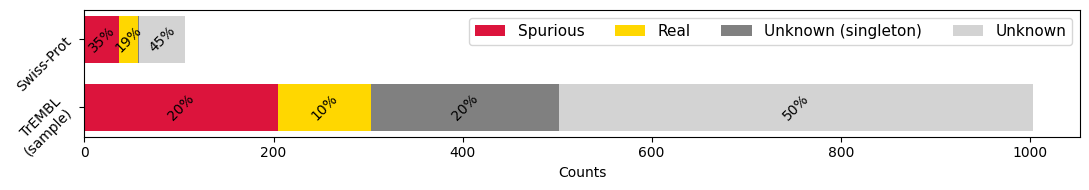

In [32]:
check_summary = {"TrEMBL\n(sample)": traf_sum, "Swiss-Prot": spaf_sum}

categories = list(check_summary.keys())

af_values = [check_summary[c]["Spurious"] for c in categories]
sp_values = [check_summary[c]["Genuine"] for c in categories]
singletons_values = [check_summary[c].get("Singletons", 0) for c in categories]
other_values = [
    check_summary[c]["Unknown"] - check_summary[c].get("Singletons", 0)
    for c in categories
]

totals = (
    np.array(af_values)
    + np.array(sp_values)
    + np.array(singletons_values)
    + np.array(other_values)
)

fig, ax = plt.subplots(figsize=(11, 2))
y_pos = np.arange(len(categories))
bar_height = 0.7

left = np.zeros(len(categories))
ax.barh(y_pos, af_values, bar_height, label="Spurious", color="crimson", left=left)
left += af_values
ax.barh(y_pos, sp_values, bar_height, label="Real", color="gold", left=left)
left += sp_values
ax.barh(
    y_pos,
    singletons_values,
    bar_height,
    label="Unknown (singleton)",
    color="gray",
    left=left,
)
left += singletons_values
ax.barh(y_pos, other_values, bar_height, label="Unknown", color="lightgray", left=left)

ax.set_yticks(y_pos)
ax.set_yticklabels(categories, rotation=45, ha="right")
ax.set_xlabel("Counts", fontsize=10)

for i, cat in enumerate(categories):
    af_pct = af_values[i] / totals[i] * 100
    sp_pct = sp_values[i] / totals[i] * 100
    singletons_pct = singletons_values[i] / totals[i] * 100
    other_pct = other_values[i] / totals[i] * 100

    segments = [
        (af_pct, 0, af_values[i]),
        (sp_pct, af_values[i], sp_values[i]),
        (
            singletons_pct,
            af_values[i] + sp_values[i],
            singletons_values[i],
        ),
        (
            other_pct,
            af_values[i] + sp_values[i] + singletons_values[i],
            other_values[i],
        ),
    ]

    for pct, left_pos, count in segments:
        if pct > 3:  # only label if at least 3%
            ax.text(
                left_pos + count / 2,
                i,
                f"{pct:.0f}%",
                ha="center",
                va="center",
                fontsize=10,
                rotation=45,
            )

ax.legend(loc="upper right", fontsize=11, ncol=4)
plt.tight_layout()
plt.show()

/nfs/research/agb/research/ako/software/miniforge3/envs/pdb2/lib/python3.13/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/nfs/research/agb/research/ako/software/miniforge3/envs/pdb2/lib/python3.13/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work be

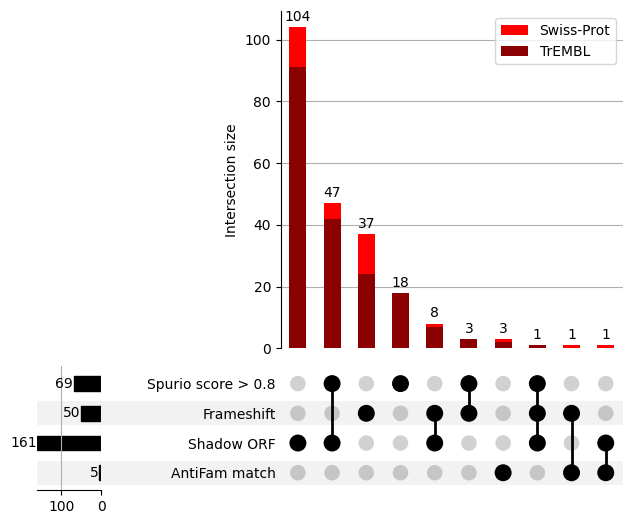

In [33]:
def get_protein_data(df, source_name):
    cat1 = set(df[df["AntiFam count"] > 0]["uniprot_id"])
    cat2 = set(df[df["Shadow score"] < 0]["uniprot_id"])
    cat3 = set(df[df["Frameshift score"] < 0]["uniprot_id"])
    cat4 = set(df[df["Spurio score"] > 0.8]["uniprot_id"])

    all_proteins = cat1 | cat2 | cat3 | cat4

    data = []
    for protein_id in all_proteins:
        data.append(
            {
                "uniprot_id": protein_id,
                "source": source_name,
                "AntiFam match": protein_id in cat1,
                "Shadow ORF": protein_id in cat2,
                "Frameshift": protein_id in cat3,
                "Spurio score > 0.8": protein_id in cat4,
            }
        )
    return pd.DataFrame(data)


df_traf = get_protein_data(spurious_traf_df, "TrEMBL")
df_spaf = get_protein_data(spurious_spaf_df, "Swiss-Prot")

df_combined = pd.concat([df_traf, df_spaf], ignore_index=True)

category_names = ["AntiFam match", "Shadow ORF", "Frameshift", "Spurio score > 0.8"]
df_upset = df_combined.set_index(category_names)

upset = UpSet(
    df_upset,
    show_counts=True,
    sort_by="cardinality",
    sort_categories_by=None,
    intersection_plot_elements=0,
)

upset.add_stacked_bars(
    by="source", colors=["red", "darkred"], title="Intersection size", elements=10
)

upset.plot()

# plt.savefig("results/spurious_upset_stacked.png", dpi=300)
plt.show()

In [ ]:
candidates = df_combined[
    ((df_combined["Shadow score"] < 0) | (df_combined["Frameshift score"] > 0))
    & (df_combined["Spurio score"] > 0.8)
]

candidates.to_csv(
    "results/spurious_candidates.tsv",
    index=False,
    sep="\t",
)